In [1]:
import time
import warnings
from html import escape
from IPython.display import display

warnings.filterwarnings("ignore", message="IProgress not found")

import blackjax
import jax
import jax.numpy as jnp
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib_inline
import numpy as np
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS

jax.config.update("jax_enable_x64", True)
matplotlib_inline.backend_inline.set_matplotlib_formats("svg", "pdf")


In [2]:
# BOOK_FIGURE_STYLE_CELL
FIGURE_SIZES = {
    "full_landscape": (4.50, 2.55),
    "full_standard": (4.50, 3.10),
    "full_tall": (4.50, 4.80),
    "half_standard": (2.15, 1.70),
    "half_tall": (2.15, 2.20),
}

CHAIN_STYLES = [
    ("0.10", "-"),
    ("0.35", "--"),
    ("0.55", "-."),
    ("0.70", ":"),
]

mpl.rcParams.update(
    {
        "figure.figsize": FIGURE_SIZES["half_standard"],
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.02,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "font.family": "sans-serif",
        "font.sans-serif": ["DejaVu Sans", "Arial", "Liberation Sans"],
        "axes.labelsize": 9,
        "axes.titlesize": 9,
        "axes.linewidth": 0.8,
        "axes.grid": False,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "xtick.major.width": 0.8,
        "ytick.major.width": 0.8,
        "legend.fontsize": 8,
        "legend.frameon": False,
        "lines.linewidth": 1.5,
        "lines.markersize": 4,
        "patch.linewidth": 0.8,
    }
)


def new_figure(size="half_standard", nrows=1, ncols=1, **kwargs):
    return plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=FIGURE_SIZES[size],
        constrained_layout=True,
        squeeze=kwargs.pop("squeeze", True),
        **kwargs,
    )


def label_panels(axes):
    for index, axis in enumerate(np.atleast_1d(axes).ravel()):
        axis.text(
            0.02,
            0.98,
            f"({chr(97 + index)})",
            transform=axis.transAxes,
            fontsize=9,
            fontweight="bold",
            va="top",
            ha="left",
        )


def finalize_axes(axes):
    for axis in np.atleast_1d(axes).ravel():
        axis.grid(False)
        axis.spines["top"].set_visible(False)
        axis.spines["right"].set_visible(False)


def display_book_table(
    headers,
    rows,
    *,
    latex_headers=None,
    latex_rows=None,
    column_spec=None,
):
    widths = [len(str(header)) for header in headers]
    for row in rows:
        widths = [
            max(width, len(str(value)))
            for width, value in zip(widths, row)
        ]
    plain_lines = [
        "  ".join(str(value).ljust(width) for value, width in zip(headers, widths)),
        "  ".join("-" * width for width in widths),
    ]
    plain_lines.extend(
        "  ".join(str(value).ljust(width) for value, width in zip(row, widths))
        for row in rows
    )

    html_header = "".join(f"<th>{escape(str(value))}</th>" for value in headers)
    html_rows = "".join(
        "<tr>" + "".join(f"<td>{escape(str(value))}</td>" for value in row) + "</tr>"
        for row in rows
    )

    if latex_headers is None:
        latex_headers = [rf"\text{{{value}}}" for value in headers]
    if latex_rows is None:
        latex_rows = [[rf"\text{{{value}}}" for value in row] for row in rows]
    if column_spec is None:
        column_spec = "l" + "r" * (len(headers) - 1)
    latex = (
        rf"\begin{{array}}{{{column_spec}}}\hline "
        + " & ".join(latex_headers)
        + r" \\ \hline "
        + r" \\ ".join(" & ".join(row) for row in latex_rows)
        + r" \\ \hline\end{array}"
    )

    display(
        {
            "text/plain": "\n".join(plain_lines),
            "text/html": (
                '<table class="table table-sm"><thead><tr>'
                + html_header
                + "</tr></thead><tbody>"
                + html_rows
                + "</tbody></table>"
            ),
            "text/latex": latex,
        },
        raw=True,
    )


# Inferring Thermal Conductivity


## Layered heat-conduction model

Consider a nondimensional rod on $[0,1]$. Its steady temperature $u(x)$ satisfies

$$
-\frac{d}{dx}\left(k(x)\frac{du}{dx}\right)=q(x),
\qquad
q(x)=\frac{1}{2}+\frac{1}{2}\sin(\pi x),
$$

with fixed boundary temperatures

$$
u(0)=u(1)=0.
$$

The rod contains two materials separated at the known interface $x=1/2$:

$$
k(x)=
\begin{cases}
k_{\mathrm L}, & 0\leq x<1/2,\\
k_{\mathrm R}, & 1/2\leq x\leq 1,
\end{cases}
\qquad
k_{\mathrm L}>0,
\quad
k_{\mathrm R}>0.
$$

Temperature and heat flux are continuous across the interface:

$$
u(1/2^-)=u(1/2^+),
\qquad
k_{\mathrm L}u_x(1/2^-)=k_{\mathrm R}u_x(1/2^+).
$$

Only $k_{\mathrm L}$ and $k_{\mathrm R}$ are inferred. The source, interface location, and boundary temperatures are treated as known. This example specializes the preceding function-space formulation to a fixed two-parameter coefficient family {cite:p}`kaipio2006statistical`.


## Conservative discretization

Let $x_i=ih$ for $i=0,\ldots,N$, where $h=1/N$, and assign the conductivity $k_{i+1/2}$ to the segment between $x_i$ and $x_{i+1}$. For each interior node, the conservative face-flux discretization is

$$
-\frac{
k_{i+1/2}(u_{i+1}-u_i)
-k_{i-1/2}(u_i-u_{i-1})
}{h^2}
=q(x_i),
\qquad
i=1,\ldots,N-1,
$$

with $u_0=u_N=0$. The interface coincides with a grid node, so each face lies entirely in one material. At the interface node, the stencil enforces conservative flux balance: the two neighboring face fluxes differ by the source integrated over the control volume, and this balance approaches the continuum flux-continuity condition as $h\to0$. The implementation uses $N=80$ segments and differentiates through the resulting dense $79\times79$ linear solve. The dense representation keeps the example transparent; large PDE systems require sparse solvers and adjoint-based derivatives.


In [3]:
num_segments = 80
x = jnp.linspace(0.0, 1.0, num_segments + 1)
h = x[1] - x[0]
segment_centers = 0.5 * (x[:-1] + x[1:])
source_values = 0.5 + 0.5 * jnp.sin(jnp.pi * x[1:-1])


def conductivity_faces(theta_left, theta_right):
    k_left = jnp.exp(theta_left)
    k_right = jnp.exp(theta_right)
    return jnp.where(segment_centers < 0.5, k_left, k_right)


@jax.jit
def solve_temperature(theta_left, theta_right):
    conductivity = conductivity_faces(theta_left, theta_right)
    diagonal = (conductivity[:-1] + conductivity[1:]) / h**2
    off_diagonal = -conductivity[1:-1] / h**2
    matrix = (
        jnp.diag(diagonal)
        + jnp.diag(off_diagonal, -1)
        + jnp.diag(off_diagonal, 1)
    )
    interior_temperature = jnp.linalg.solve(matrix, source_values)
    return jnp.concatenate(
        [jnp.zeros(1), interior_temperature, jnp.zeros(1)]
    )


## Synthetic observations

The data in this example are author-generated and synthetic. To avoid generating and fitting the data with the same numerical solver, the noise-free temperature is computed from the continuum solution. Define

$$
Q(x)=\int_0^x q(s)\,ds.
$$

The heat flux satisfies $-k(x)u_x(x)=Q(x)+C$, where the constant $C$ is determined by $u(1)=0$. Integrating this expression gives the exact temperature used to generate the observations.

The generating values are

$$
k_{\mathrm L}^\dagger=0.7,
\qquad
k_{\mathrm R}^\dagger=2.2,
\qquad
\sigma^\dagger=0.004.
$$

Independent Gaussian noise is added with random seed 20260919. Twelve sensor values form the calibration data. Three additional sensor values are held out and used only for the predictive check. The difference between the continuum solution and the 80-segment numerical solution is reported below relative to $\sigma^\dagger$; this checks that discretization error is negligible for this constructed experiment {cite:p}`kaipio2007statistical,cotter2010approximation`.


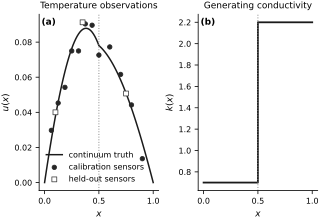

Random seed: 20260919
Calibration sensors: 12; held-out sensors: 3
Maximum coarse-grid error at calibration sensors: 4.985e-06
Error-to-noise ratio: 0.0012


In [4]:
def integrated_cumulative_source(location):
    location = np.asarray(location, dtype=float)
    return (
        0.25 * location**2
        + location / (2.0 * np.pi)
        - np.sin(np.pi * location) / (2.0 * np.pi**2)
    )


def exact_temperature(location, k_left, k_right, interface=0.5):
    location = np.asarray(location, dtype=float)
    left_length = np.minimum(location, interface)
    right_length = np.maximum(location - interface, 0.0)

    reciprocal_integral = left_length / k_left + right_length / k_right
    source_integral = (
        integrated_cumulative_source(left_length) / k_left
        + np.where(
            location > interface,
            (
                integrated_cumulative_source(location)
                - integrated_cumulative_source(interface)
            )
            / k_right,
            0.0,
        )
    )

    reciprocal_total = interface / k_left + (1.0 - interface) / k_right
    source_total = (
        integrated_cumulative_source(interface) / k_left
        + (
            integrated_cumulative_source(1.0)
            - integrated_cumulative_source(interface)
        )
        / k_right
    )
    flux_constant = -source_total / reciprocal_total
    return -(source_integral + flux_constant * reciprocal_integral)


true_k_left = 0.7
true_k_right = 2.2
true_sigma = 0.004
true_theta = jnp.log(jnp.array([true_k_left, true_k_right]))
exact_temperature_field = exact_temperature(
    np.asarray(x), true_k_left, true_k_right
)

calibration_idx = jnp.array([5, 10, 15, 20, 25, 30, 35, 40, 48, 56, 64, 72])
validation_idx = jnp.array([8, 28, 60])
calibration_x = x[calibration_idx]
validation_x = x[validation_idx]

random_seed = 20260919
master_key = jax.random.PRNGKey(random_seed)
calibration_key, validation_key, mcmc_key, predictive_key = jax.random.split(
    master_key, 4
)
calibration_observations = (
    jnp.asarray(exact_temperature_field[np.asarray(calibration_idx)])
    + true_sigma
    * jax.random.normal(calibration_key, calibration_idx.shape)
)
validation_observations = (
    jnp.asarray(exact_temperature_field[np.asarray(validation_idx)])
    + true_sigma
    * jax.random.normal(validation_key, validation_idx.shape)
)

coarse_truth = np.asarray(solve_temperature(*true_theta))
maximum_sensor_error = np.max(
    np.abs(
        coarse_truth[np.asarray(calibration_idx)]
        - exact_temperature_field[np.asarray(calibration_idx)]
    )
)

fig, axes = new_figure("full_standard", nrows=1, ncols=2)
axes[0].plot(x, exact_temperature_field, color="0.10", label="continuum truth")
axes[0].scatter(
    calibration_x,
    calibration_observations,
    color="0.15",
    marker="o",
    s=20,
    label="calibration sensors",
    zorder=3,
)
axes[0].scatter(
    validation_x,
    validation_observations,
    facecolors="white",
    edgecolors="0.25",
    marker="s",
    s=24,
    label="held-out sensors",
    zorder=3,
)
axes[0].axvline(0.5, color="0.55", linestyle=":", linewidth=1.0)
axes[0].set_xlabel("$x$")
axes[0].set_ylabel("$u(x)$")
axes[0].set_title("Temperature observations")
axes[0].legend(loc="best")

true_conductivity = np.where(
    np.asarray(segment_centers) < 0.5, true_k_left, true_k_right
)
true_conductivity_step = np.append(true_conductivity, true_conductivity[-1])
axes[1].step(
    x,
    true_conductivity_step,
    where="post",
    color="0.10",
    linewidth=1.8,
)
axes[1].axvline(0.5, color="0.55", linestyle=":", linewidth=1.0)
axes[1].set_xlabel("$x$")
axes[1].set_ylabel("$k(x)$")
axes[1].set_title("Generating conductivity")

label_panels(axes)
finalize_axes(axes)
plt.show()

print(f"Random seed: {random_seed}")
print(f"Calibration sensors: {calibration_idx.size}; held-out sensors: {validation_idx.size}")
print(f"Maximum coarse-grid error at calibration sensors: {maximum_sensor_error:.3e}")
print(f"Error-to-noise ratio: {maximum_sensor_error / true_sigma:.4f}")


## Bayesian model

The sampled parameters are the log-conductivities

$$
\theta_{\mathrm L}=\log k_{\mathrm L},
\qquad
\theta_{\mathrm R}=\log k_{\mathrm R}.
$$

This parameterization enforces $k_{\mathrm L}>0$ and $k_{\mathrm R}>0$. Let $x_{s_j}$ denote the $j$th calibration-sensor location, and let $u_h(x_{s_j};\boldsymbol{\theta})$ denote the 80-segment prediction. The observation model is

$$
y_j=u_h(x_{s_j};\boldsymbol{\theta})+\epsilon_j,
\qquad
\epsilon_j\overset{\mathrm{iid}}{\sim}\mathcal{N}(0,\sigma^2).
$$

The independent priors are

$$
\theta_{\mathrm L}\sim\mathcal{N}(\log 1,0.5^2),
\qquad
\theta_{\mathrm R}\sim\mathcal{N}(\log 2,0.5^2),
\qquad
\sigma\sim\operatorname{HalfNormal}(0.02).
$$

The posterior is therefore proportional to

$$
p(\theta_{\mathrm L})p(\theta_{\mathrm R})p(\sigma)
\prod_{j=1}^{12}
p(y_j\mid\theta_{\mathrm L},\theta_{\mathrm R},\sigma).
$$

The held-out observations do not appear in this product. The priors encode plausible conductivity and noise scales; positivity comes from the exponential map.


In [5]:
def thermal_inverse_model(sensor_idx, observations=None):
    theta_left = numpyro.sample(
        "theta_left", dist.Normal(jnp.log(1.0), 0.5)
    )
    theta_right = numpyro.sample(
        "theta_right", dist.Normal(jnp.log(2.0), 0.5)
    )
    sigma = numpyro.sample("sigma", dist.HalfNormal(0.02))

    temperature = solve_temperature(theta_left, theta_right)
    numpyro.sample(
        "observations",
        dist.Normal(temperature[sensor_idx], sigma).to_event(1),
        obs=observations,
    )


## Posterior computation and diagnostics

Four vectorized NUTS chains each use 1,000 warmup transitions and retain 2,000 inference draws. Warmup adapts the step size and mass matrix; the inference phase then holds them fixed. The target acceptance probability is $0.9$, and no draws are thinned. We report rank-normalized split $\widehat{R}$, bulk and tail effective sample sizes, Monte Carlo standard errors, divergences, and the variable number of leapfrog steps used by NUTS {cite:p}`hoffman2014nuts,vehtari2021rank`. A depth-cap event means that NUTS reached the prescribed maximum tree depth before its usual termination rule. E-BFMI compares changes in Hamiltonian energy between successive draws with the marginal energy variation; a low value can signal poor energy exploration {cite:p}`betancourt2017conceptual`. The implementation uses NumPyro {cite:p}`phan2019numpyro`.

Every leapfrog step differentiates through the $79\times79$ linear solve. The wall time below is a machine-specific measurement, while the transition and leapfrog-step counts describe the algorithmic work in this run.


In [6]:
num_chains = 4
num_warmup = 1_000
num_samples = 2_000
maximum_tree_depth = 8

kernel = NUTS(
    thermal_inverse_model,
    target_accept_prob=0.9,
    max_tree_depth=maximum_tree_depth,
)
mcmc = MCMC(
    kernel,
    num_warmup=num_warmup,
    num_samples=num_samples,
    num_chains=num_chains,
    chain_method="vectorized",
    progress_bar=False,
)

start_time = time.perf_counter()
mcmc.run(
    mcmc_key,
    sensor_idx=calibration_idx,
    observations=calibration_observations,
    extra_fields=("accept_prob", "diverging", "energy", "num_steps"),
)
posterior_samples = mcmc.get_samples(group_by_chain=True)
jax.tree_util.tree_map(lambda value: value.block_until_ready(), posterior_samples)
elapsed_seconds = time.perf_counter() - start_time

extra_fields = {
    name: np.asarray(value)
    for name, value in mcmc.get_extra_fields(group_by_chain=True).items()
}
posterior_by_chain = {
    "k_left": np.exp(np.asarray(posterior_samples["theta_left"])),
    "k_right": np.exp(np.asarray(posterior_samples["theta_right"])),
    "sigma": np.asarray(posterior_samples["sigma"]),
}

divergence_count = int(extra_fields["diverging"].sum())
depth_cap = 2**maximum_tree_depth - 1
depth_cap_count = int((extra_fields["num_steps"] >= depth_cap).sum())
retained_leapfrog_steps = int(extra_fields["num_steps"].sum())
energy = extra_fields["energy"]
ebfmi = np.mean(np.diff(energy, axis=1) ** 2, axis=1) / np.var(
    energy, axis=1, ddof=1
)

print(f"Backend: {jax.default_backend()}")
print(
    f"Warmup transitions: {num_chains * num_warmup:,}; "
    f"retained transitions: {num_chains * num_samples:,}"
)
print(f"Wall time including compilation and warmup: {elapsed_seconds:.2f} s")
print(f"Mean acceptance probability: {extra_fields['accept_prob'].mean():.3f}")
print(f"Divergences: {divergence_count}")
print(f"Depth-cap events: {depth_cap_count}")
print(
    "Retained-phase leapfrog steps: "
    f"{retained_leapfrog_steps:,} total; "
    f"median {np.median(extra_fields['num_steps']):.0f}; "
    f"maximum {extra_fields['num_steps'].max()}"
)
print(f"Minimum chain E-BFMI: {ebfmi.min():.3f}")


Backend: cpu
Warmup transitions: 4,000; retained transitions: 8,000
Wall time including compilation and warmup: 10.45 s
Mean acceptance probability: 0.969
Divergences: 0
Depth-cap events: 0
Retained-phase leapfrog steps: 94,916 total; median 15; maximum 63
Minimum chain E-BFMI: 0.720


In [7]:
truth = {
    "k_left": true_k_left,
    "k_right": true_k_right,
    "sigma": true_sigma,
}
plain_labels = {
    "k_left": "k_L",
    "k_right": "k_R",
    "sigma": "sigma",
}
latex_labels = {
    "k_left": r"k_{\mathrm L}",
    "k_right": r"k_{\mathrm R}",
    "sigma": r"\sigma",
}

posterior_rows = []
posterior_latex_rows = []
diagnostic_rows = []
diagnostic_latex_rows = []

for name, values in posterior_by_chain.items():
    flattened = values.reshape(-1)
    bulk_ess = float(blackjax.ess_bulk(values))
    tail_ess = float(blackjax.ess_tail(values))
    rhat = float(blackjax.rhat(values))
    lower, upper = np.quantile(flattened, [0.05, 0.95])
    mean = flattened.mean()
    mcse_mean = flattened.std(ddof=1) / np.sqrt(bulk_ess)

    if name == "sigma":
        number_format = ".5f"
    else:
        number_format = ".4f"

    posterior_rows.append(
        [
            plain_labels[name],
            format(truth[name], number_format),
            format(mean, number_format),
            f"[{format(lower, number_format)}, {format(upper, number_format)}]",
            format(mcse_mean, number_format),
        ]
    )
    posterior_latex_rows.append(
        [
            latex_labels[name],
            format(truth[name], number_format),
            format(mean, number_format),
            rf"[{format(lower, number_format)},\ {format(upper, number_format)}]",
            format(mcse_mean, number_format),
        ]
    )
    diagnostic_rows.append(
        [plain_labels[name], f"{rhat:.3f}", f"{bulk_ess:.0f}", f"{tail_ess:.0f}"]
    )
    diagnostic_latex_rows.append(
        [latex_labels[name], f"{rhat:.3f}", f"{bulk_ess:.0f}", f"{tail_ess:.0f}"]
    )

display_book_table(
    ["Parameter", "Truth", "Mean", "90% interval", "MCSE(mean)"],
    posterior_rows,
    latex_headers=[
        r"\text{Parameter}",
        r"\text{Truth}",
        r"\text{Mean}",
        r"90\%\ \text{interval}",
        r"\operatorname{MCSE}(\text{mean})",
    ],
    latex_rows=posterior_latex_rows,
    column_spec="lrrrr",
)

display_book_table(
    ["Parameter", "R-hat", "Bulk ESS", "Tail ESS"],
    diagnostic_rows,
    latex_headers=[
        r"\text{Parameter}",
        r"\widehat R",
        r"\text{Bulk ESS}",
        r"\text{Tail ESS}",
    ],
    latex_rows=diagnostic_latex_rows,
    column_spec="lrrr",
)


Parameter,Truth,Mean,90% interval,MCSE(mean)
k_L,0.7000,0.8116,"[0.6774, 0.9807]",0.0019
k_R,2.2000,2.0409,"[1.7390, 2.3359]",0.0037
sigma,0.00400,0.00670,"[0.00451, 0.01006]",0.00004


Parameter,R-hat,Bulk ESS,Tail ESS
k_L,1.002,2543,2740
k_R,1.002,2463,2851
sigma,1.001,2566,3076


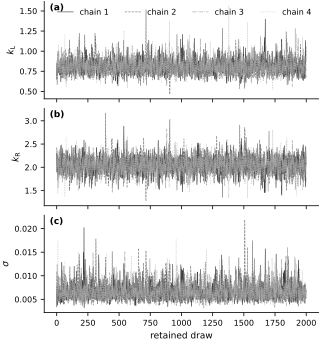

In [8]:
trace_labels = {
    "k_left": r"$k_{\mathrm{L}}$",
    "k_right": r"$k_{\mathrm{R}}$",
    "sigma": r"$\sigma$",
}

fig, axes = new_figure("full_tall", nrows=3, ncols=1, sharex=True)
draw = np.arange(num_samples)
for axis, (name, values) in zip(axes, posterior_by_chain.items()):
    for chain_index, (gray, linestyle) in enumerate(CHAIN_STYLES):
        axis.plot(
            draw,
            values[chain_index],
            color=gray,
            linestyle=linestyle,
            linewidth=0.65,
            alpha=0.85,
            label=f"chain {chain_index + 1}",
        )
    axis.set_ylabel(trace_labels[name])

axes[0].legend(ncol=4, loc="upper right")
axes[-1].set_xlabel("retained draw")
label_panels(axes)
finalize_axes(axes)
plt.show()


## Posterior information

The physical-scale intervals summarize uncertainty in the conductivities, while the diagnostics assess the Monte Carlo approximation. Here $\widehat{R}\leq1.002$, every reported effective sample size is at least 2,463, there are no divergences or depth-cap events, and the minimum chain E-BFMI is $0.720$. These results show no evident sampler warning; they do not establish that the physical or statistical model is correct. The joint posterior is also important: changes in one conductivity can be partly offset by changes in the other while preserving similar temperatures at the available sensors. The sample correlation below quantifies this tradeoff for the present data and prior; it is not a structural-identifiability result.


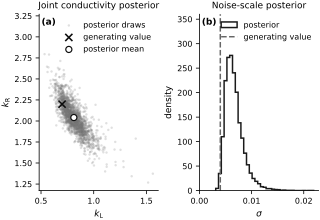

Posterior correlation corr(k_L, k_R): -0.794


In [9]:
k_left_draws = posterior_by_chain["k_left"].reshape(-1)
k_right_draws = posterior_by_chain["k_right"].reshape(-1)
sigma_draws = posterior_by_chain["sigma"].reshape(-1)
conductivity_correlation = np.corrcoef(k_left_draws, k_right_draws)[0, 1]

fig, axes = new_figure("full_standard", nrows=1, ncols=2)
display_stride = 4
axes[0].scatter(
    k_left_draws[::display_stride],
    k_right_draws[::display_stride],
    s=6,
    color="0.45",
    alpha=0.22,
    linewidths=0,
    label="posterior draws",
)
axes[0].scatter(
    [true_k_left],
    [true_k_right],
    marker="x",
    s=52,
    color="0.05",
    linewidths=1.6,
    label="generating value",
)
axes[0].scatter(
    [k_left_draws.mean()],
    [k_right_draws.mean()],
    marker="o",
    s=38,
    facecolors="white",
    edgecolors="0.05",
    linewidths=1.2,
    label="posterior mean",
)
axes[0].set_xlabel(r"$k_{\mathrm{L}}$")
axes[0].set_ylabel(r"$k_{\mathrm{R}}$")
axes[0].set_title("Joint conductivity posterior")
axes[0].legend(loc="best")

axes[1].hist(
    sigma_draws,
    bins=35,
    density=True,
    histtype="step",
    color="0.10",
    linewidth=1.5,
    label="posterior",
)
axes[1].axvline(
    true_sigma,
    color="0.40",
    linestyle="--",
    linewidth=1.5,
    label="generating value",
)
axes[1].set_xlabel(r"$\sigma$")
axes[1].set_ylabel("density")
axes[1].set_title("Noise-scale posterior")
axes[1].set_xlim(left=0.0)
axes[1].set_ylim(top=360)
axes[1].legend(loc="upper right")

label_panels(axes)
finalize_axes(axes)
plt.show()

print(f"Posterior correlation corr(k_L, k_R): {conductivity_correlation:.3f}")


## Temperature field and predictive check

The posterior over $(k_{\mathrm L},k_{\mathrm R})$ induces uncertainty in the latent temperature and conductivity fields. The bands below use 2,000 evenly spaced posterior draws. A separate posterior predictive calculation adds measurement noise to the latent temperatures at the three held-out sensors. This distinguishes uncertainty in $u(x)$ from uncertainty in a future measurement.


In [10]:
flat_theta_left = np.asarray(posterior_samples["theta_left"]).reshape(-1)
flat_theta_right = np.asarray(posterior_samples["theta_right"]).reshape(-1)
flat_sigma = np.asarray(posterior_samples["sigma"]).reshape(-1)

num_predictive_draws = 2_000
predictive_indices = np.linspace(
    0, flat_theta_left.size - 1, num_predictive_draws, dtype=int
)
posterior_temperature = np.asarray(
    jax.vmap(solve_temperature)(
        jnp.asarray(flat_theta_left[predictive_indices]),
        jnp.asarray(flat_theta_right[predictive_indices]),
    )
)
posterior_sigma = flat_sigma[predictive_indices]

temperature_mean = posterior_temperature.mean(axis=0)
temperature_lower, temperature_upper = np.quantile(
    posterior_temperature, [0.05, 0.95], axis=0
)

predictive_noise = np.asarray(
    jax.random.normal(
        predictive_key,
        (num_predictive_draws, validation_idx.size),
    )
) * posterior_sigma[:, None]
validation_replicates = (
    posterior_temperature[:, np.asarray(validation_idx)] + predictive_noise
)
validation_mean = validation_replicates.mean(axis=0)
validation_lower, validation_upper = np.quantile(
    validation_replicates, [0.05, 0.95], axis=0
)

validation_rows = []
validation_latex_rows = []
for location, observed, mean, lower, upper in zip(
    np.asarray(validation_x),
    np.asarray(validation_observations),
    validation_mean,
    validation_lower,
    validation_upper,
):
    validation_rows.append(
        [
            f"{location:.2f}",
            f"{observed:.5f}",
            f"{mean:.5f}",
            f"[{lower:.5f}, {upper:.5f}]",
        ]
    )
    validation_latex_rows.append(
        [
            f"{location:.2f}",
            f"{observed:.5f}",
            f"{mean:.5f}",
            rf"[{lower:.5f},\ {upper:.5f}]",
        ]
    )

display_book_table(
    ["x", "Observed", "Predictive mean", "90% predictive interval"],
    validation_rows,
    latex_headers=[
        "x",
        r"y_{\mathrm{obs}}",
        r"\mathbb{E}[y_{\mathrm{rep}}\mid\mathbf{y}]",
        r"90\%\ \text{predictive interval}",
    ],
    latex_rows=validation_latex_rows,
    column_spec="rrrr",
)

validation_covered = (
    (np.asarray(validation_observations) >= validation_lower)
    & (np.asarray(validation_observations) <= validation_upper)
)
print(
    "Held-out observations inside their 90% posterior predictive intervals: "
    f"{validation_covered.sum()} of {validation_covered.size}"
)

k_left_subset = k_left_draws[predictive_indices]
k_right_subset = k_right_draws[predictive_indices]
k_left_interval = np.quantile(k_left_subset, [0.05, 0.95])
k_right_interval = np.quantile(k_right_subset, [0.05, 0.95])

mean_conductivity = np.where(
    np.asarray(segment_centers) < 0.5,
    k_left_subset.mean(),
    k_right_subset.mean(),
)
lower_conductivity = np.where(
    np.asarray(segment_centers) < 0.5,
    k_left_interval[0],
    k_right_interval[0],
)
upper_conductivity = np.where(
    np.asarray(segment_centers) < 0.5,
    k_left_interval[1],
    k_right_interval[1],
)

mean_conductivity_step = np.append(mean_conductivity, mean_conductivity[-1])
lower_conductivity_step = np.append(lower_conductivity, lower_conductivity[-1])
upper_conductivity_step = np.append(upper_conductivity, upper_conductivity[-1])


x,Observed,Predictive mean,90% predictive interval
0.10,0.04003,0.03516,"[0.02323, 0.04676]"
0.35,0.09130,0.08415,"[0.07170, 0.09644]"
0.75,0.05073,0.05284,"[0.04065, 0.06513]"


Held-out observations inside their 90% posterior predictive intervals: 3 of 3


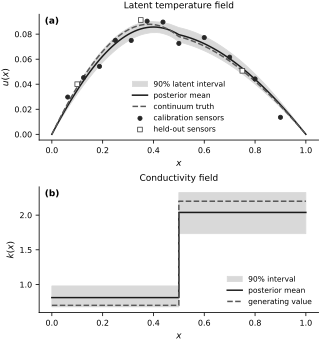

In [11]:
fig, axes = new_figure("full_tall", nrows=2, ncols=1)
axes[0].fill_between(
    x,
    temperature_lower,
    temperature_upper,
    color="0.85",
    label="90% latent interval",
)
axes[0].plot(x, temperature_mean, color="0.10", label="posterior mean")
axes[0].plot(
    x,
    exact_temperature_field,
    color="0.35",
    linestyle="--",
    label="continuum truth",
)
axes[0].scatter(
    calibration_x,
    calibration_observations,
    color="0.15",
    marker="o",
    s=18,
    label="calibration sensors",
    zorder=3,
)
axes[0].scatter(
    validation_x,
    validation_observations,
    facecolors="white",
    edgecolors="0.25",
    marker="s",
    s=22,
    label="held-out sensors",
    zorder=3,
)
axes[0].set_xlabel("$x$")
axes[0].set_ylabel("$u(x)$")
axes[0].set_title("Latent temperature field")
axes[0].legend(loc="lower center", fontsize=7.5)

axes[1].fill_between(
    x,
    lower_conductivity_step,
    upper_conductivity_step,
    step="post",
    color="0.85",
    label="90% interval",
)
axes[1].step(
    x,
    mean_conductivity_step,
    where="post",
    color="0.10",
    label="posterior mean",
)
axes[1].step(
    x,
    true_conductivity_step,
    where="post",
    color="0.35",
    linestyle="--",
    label="generating value",
)
axes[1].set_xlabel("$x$")
axes[1].set_ylabel("$k(x)$")
axes[1].set_title("Conductivity field")
axes[1].legend(loc="lower right", fontsize=7.5)

label_panels(axes)
finalize_axes(axes)
plt.show()


## Interpretation and limits

The conductivity intervals contain the generating values for this realization. The generating noise scale, $\sigma^\dagger=0.004$, lies just below its central 90% posterior interval, $[0.00451,0.01006]$; one finite-data interval miss does not by itself diagnose miscalibration. All three held-out observations lie inside their 90% posterior predictive intervals, but three held-out values are too few to assess predictive calibration and provide only a small consistency check. The negative joint-posterior correlation shows that the two conductivities remain partially confounded even though both are locally informed by the sensor layout.

The continuum data generator and coarse inference solver differ by much less than the measurement-noise scale here. The example nevertheless assumes the source, interface, boundary conditions, and two-layer parameterization are correct. It contains no process uncertainty or model-discrepancy term. The next [contaminant-location example](03_contamination.ipynb) keeps the PDE operator fixed and instead infers an unknown source location.

## Exercises

1. Retain only calibration sensors with $x<1/2$. Recompute the posterior and compare the 90% interval widths for $k_{\mathrm L}$ and $k_{\mathrm R}$ with the reported widths.
2. Regenerate the observations with $\sigma^\dagger=0.008$ and the same sensor locations. Compare the posterior standard deviations and held-out predictive intervals with the original run.
3. Replace the two-layer model by three piecewise-constant layers with fixed interfaces at $x=1/3$ and $x=2/3$ and generating conductivities $(k_1^\dagger,k_2^\dagger,k_3^\dagger)=(0.7,1.3,2.2)$. Compute the calibration-sensor Jacobian with respect to the log-conductivities at these values and compare its singular values with those of the two-layer model.
4. Run independent inferences with $N=80$, $160$, and $320$ segments. For each posterior mean $\mu$, use the $N=320$ result as the reference and call the difference at mesh $N$ numerically unresolved when $|\widehat{\mu}_N-\widehat{\mu}_{320}|\leq2\bigl(\operatorname{MCSE}_N^2+\operatorname{MCSE}_{320}^2\bigr)^{1/2}$. Apply this criterion to $k_{\mathrm L}$, $k_{\mathrm R}$, and $\sigma$.
5. Compare the present source with $q(x)=1$ and $q(x)=\sin(2\pi x)$. For each source, use the same calibration sensors, evaluate the Jacobian with respect to $(\log k_{\mathrm L},\log k_{\mathrm R})$ at $(k_{\mathrm L},k_{\mathrm R})=(0.7,2.2)$, and divide it by the known noise scale $\sigma^\dagger=0.004$. Rank the designs by the smallest singular value of this whitened Jacobian.
